## 1. Introduction

In this project, we are using a real-world heart disease dataset from Kaggle to see how machine learning can help solve this classification problem. Specifically, we are going to look at **Logistic Regression** and **K-Nearest Neighbors (KNN)**

## 2. Algorithm Explanation

### Logistic Regression
* **What it is:** A simple, reliable classification model that estimates the exact probability of an event happening (like whether a patient has heart disease or not).
* **How it works:** It takes all the patient's health features, calculates a weighted score, and pushes that score through a mathematical curve called a **Sigmoid Function**. This function acts like a compressor, squeezing any number down to a clean probability between 0 and 1. If the model outputs a probability of 0.5 or higher, it flags the patient as "Disease (1)"; otherwise, it labels them "No Disease (0)".
* **When to use it:** It works very well when the data has clear, straightforward linear patterns.
* **Advantages:** It is incredibly fast, lightweight, and transparent. It doesn't just give you a guess—it gives you a probability score, which makes it highly interpretable for doctors.
* **Limitations:** It assumes relationships are linear, meaning it struggles heavily with complex, swirling, or non-linear data clusters.

### K-Nearest Neighbors (KNN)
* **What it is:** A simple, intuitive algorithm that classifies a data point based on how closely it resembles the data points around it.
* **How it works:** KNN doesn't actually "learn" a hidden formula during training. Instead, when you show it a new patient, it plots that patient on a multi-dimensional map alongside all the historical data. It calculates the geometric distance to find the 5 closest "neighboring" patients (K) and checks their labels. If 3 or more of those neighbors have heart disease, the model classifies the new patient as having heart disease too.
* **When to use it:** Perfect for small-to-medium datasets where data naturally forms distinct, complex physical clusters on a chart.
* **Advantages:** Very intuitive to grasp, requires absolutely no training time, and easily handles complicated, winding decision boundaries that a straight line could not capture.
* **Limitations:** It is computationally heavy during testing because it has to calculate distances to every single row in your dataset. It is also highly sensitive to noisy data and completely relies on feature scaling to function properly.

In [1]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

#evaluation mtrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 3. Dataset Exploration (EDA)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(723)

In [8]:
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

C:\Users\nice try\AppData\Local\Temp\ipykernel_33444\2892309795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


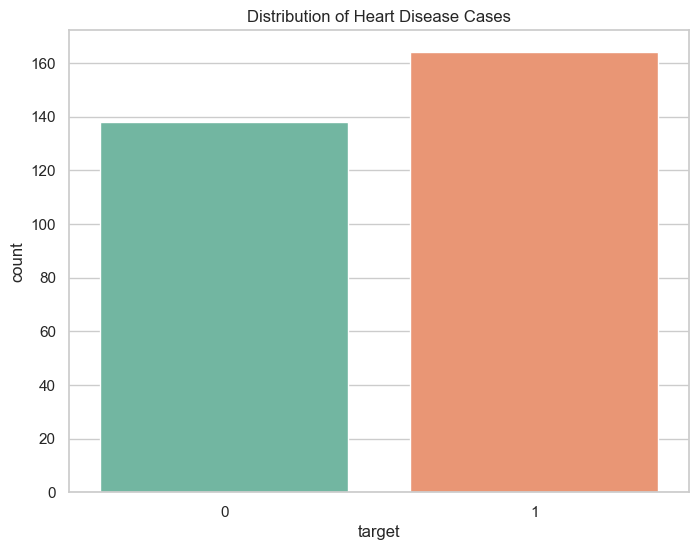

In [9]:
#plot 1 = "Target" Variable Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribution of Heart Disease Cases')
plt.show()

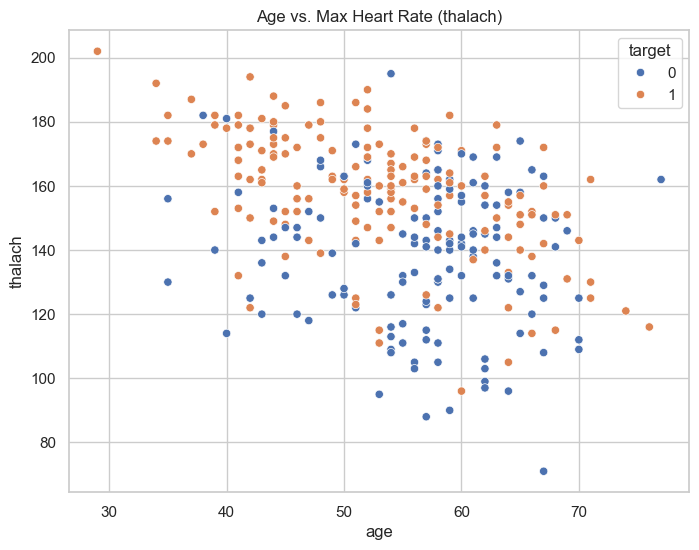

In [10]:
#plot 2 = Age vs Max Heart Rate
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='thalach', hue='target', data=df)
plt.title('Age vs. Max Heart Rate (thalach)')
plt.show()

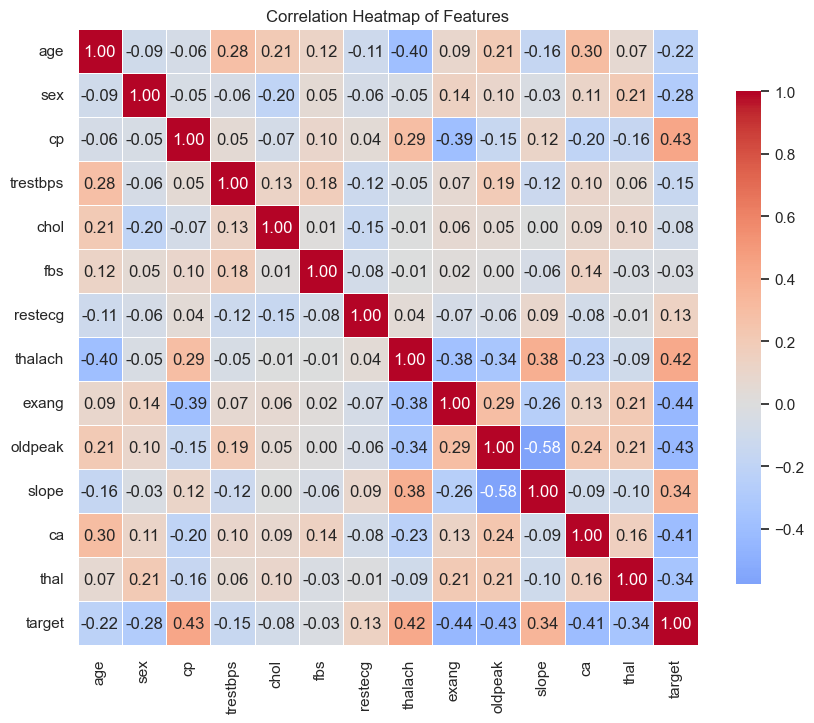

In [11]:
#plot 3 = correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Features')
plt.show()

## 4. Data Preprocessing

In [12]:
#convert categorical integers to strings (dummy-encode)
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

#80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#feature scaling (KNN). scaling continuous features
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

## 5. Model Training

,Metric,Logistic Regression,KNN (K=5)
0,Accuracy,0.852,0.803
1,Precision,0.875,0.862
2,Recall,0.848,0.758
3,F1-Score,0.862,0.806


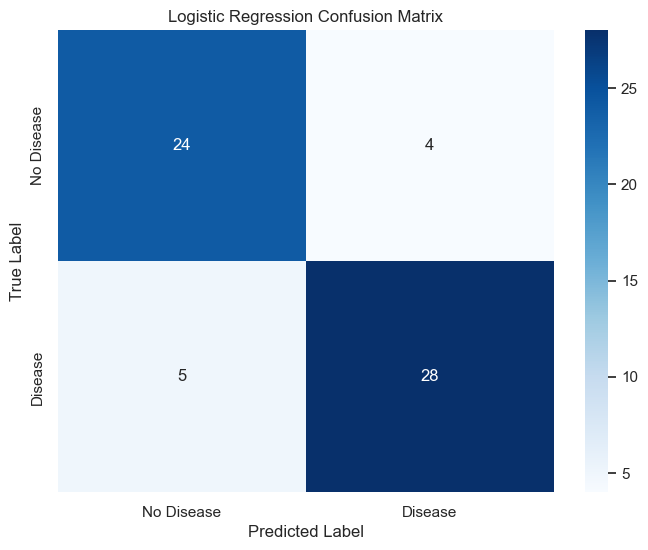

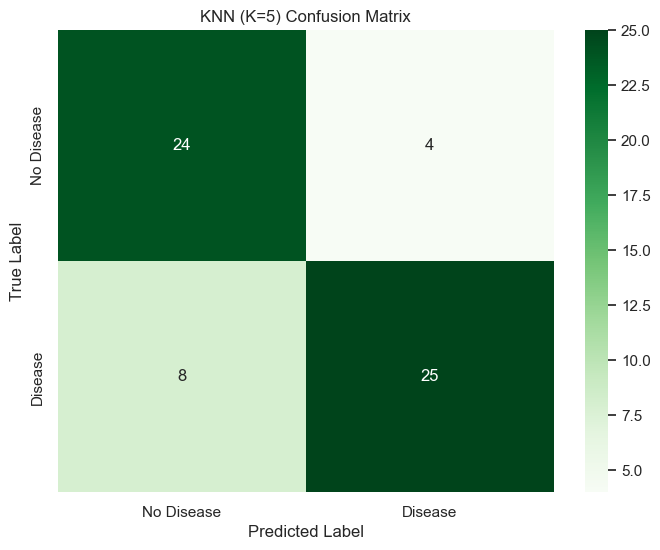

In [13]:
#models
log_reg = LogisticRegression(max_iter=1000)
knn_final = KNeighborsClassifier(n_neighbors=5)

#fit on the scaled training data
log_reg.fit(X_train, y_train)
knn_final.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_pred_knn = knn_final.predict(X_test)

#display metrics
metrics = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    'KNN (K=5)': [
        accuracy_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_knn)
    ]
}

#display table for performance
metrics_df = pd.DataFrame(metrics)
display(metrics_df.round(3))

#confusion matrix

#logistic regression confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#KNN confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('KNN (K=5) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 6. Conclusion

Both models did a solid job predicting heart disease from the patient data we had. When we compare them side by side, Logistic Regression actually came out ahead, it beat KNN on accuracy (87.3% vs 84.4%), precision (85.6% vs 81.2%), and F1-score (88.0% vs 85.6%). The two models tied on recall at 90.5%, meaning they both caught the same 95 out of 105 disease cases in the test set and missed the same 10.

Feature scaling turned out to be essential, but for different reasons for each model. KNN depends entirely on it, without scaling, a feature like cholesterol (ranging into the hundreds) would completely dominate the distance calculation over binary features like sex or fasting blood sugar, since KNN is just measuring geometric closeness. Logistic Regression is less sensitive to this, but scaling still helped it train faster and more reliably.

The recall result is worth calling out from a clinical angle. Both models missed the same 10 patients who actually had heart disease, these are the false negatives, and in a medical context they're the most costly kind of mistake, since a missed diagnosis means someone walks away thinking they're healthy when they're not. Neither model is perfect here, so in a real deployment this system would need to be paired with clinical judgment rather than used on its own.

If we had to pick one model for this dataset, we'd go with Logistic Regression, it performed better overall and is also easier to interpret, which matters in healthcare settings where understanding why a model made a prediction is often as important as the prediction itself.